# Data Exploration
This notebook focuses on the **Exploratory Data Analysis**, the goal is to understand the dataset, find patterns and prepare for Feature Engineering and Selection.
The data is already cleaned and loaded

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.data_cleaning import clean_data

df = clean_data()
df.shape, df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 101742 entries, 0 to 101765
Data columns (total 35 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   race                   101742 non-null  object
 1   gender                 101742 non-null  object
 2   age                    101742 non-null  object
 3   admission_type         101742 non-null  object
 4   discharge_disposition  101742 non-null  object
 5   admission_source       101742 non-null  object
 6   time_in_hospital       101742 non-null  int64 
 7   payer_code             101742 non-null  object
 8   medical_specialty      101742 non-null  object
 9   num_lab_procedures     101742 non-null  int64 
 10  num_procedures         101742 non-null  int64 
 11  num_medications        101742 non-null  int64 
 12  number_outpatient      101742 non-null  int64 
 13  number_emergency       101742 non-null  int64 
 14  number_inpatient       101742 non-null  int64 
 15  diag_

C:\Users\taula\OneDrive\Desktop\Sem7\DSPRO\hospital-readmission-predictor\src\data_cleaning.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_data['max_glu_serum'].fillna(0, inplace=True)
C:\Users\taula\OneDrive\Desktop\Sem7\DSPRO\hospital-readmission-predictor\src\data_cleaning.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object o

((101742, 35), None)

## Basic Statistics

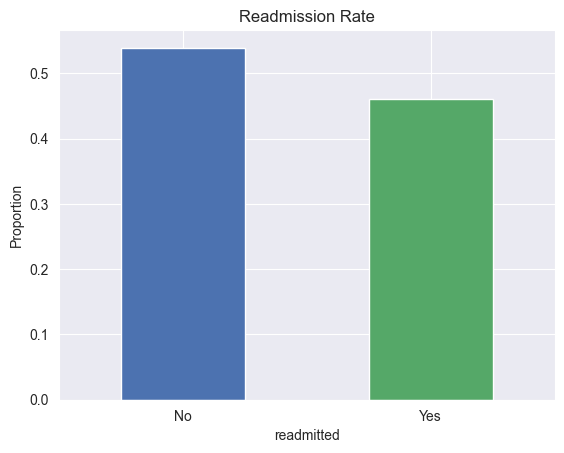

In [4]:
# Distribution of target variable
df['readmitted'].value_counts(normalize=True).plot(kind='bar', color=['#4C72B0', '#55A868'])
plt.title('Readmission Rate')
plt.ylabel('Proportion')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()


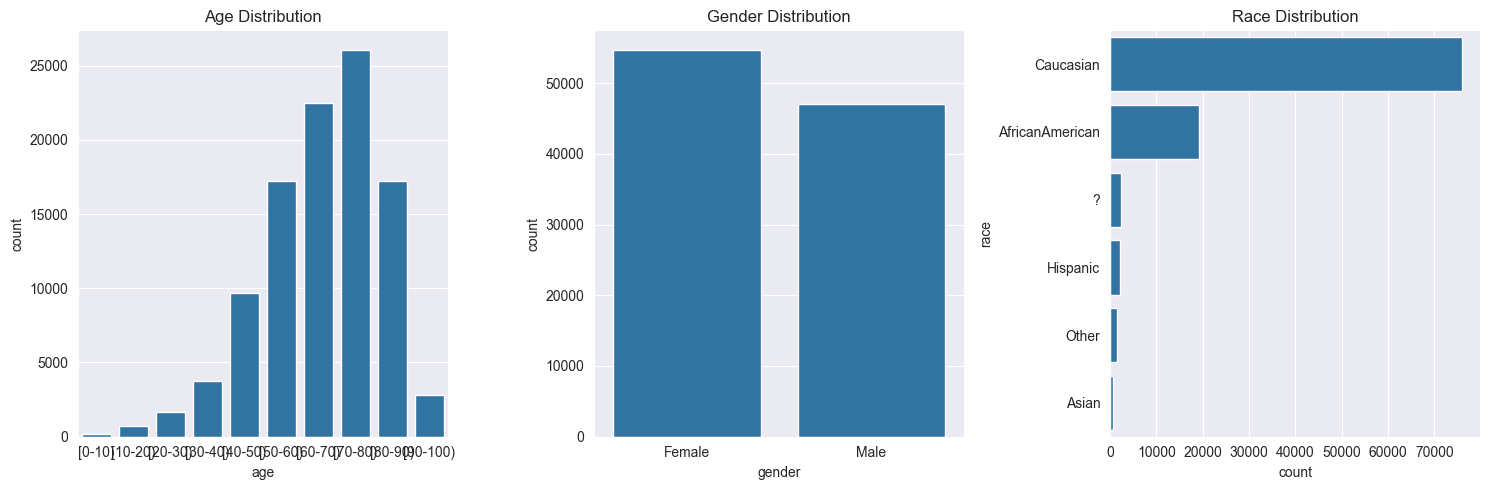

In [5]:
# Demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='age', data=df, ax=axes[0], order=sorted(df['age'].unique()))
axes[0].set_title('Age Distribution')

sns.countplot(x='gender', data=df, ax=axes[1])
axes[1].set_title('Gender Distribution')

sns.countplot(y='race', data=df, ax=axes[2], order=df['race'].value_counts().index)
axes[2].set_title('Race Distribution')

plt.tight_layout()
plt.show()


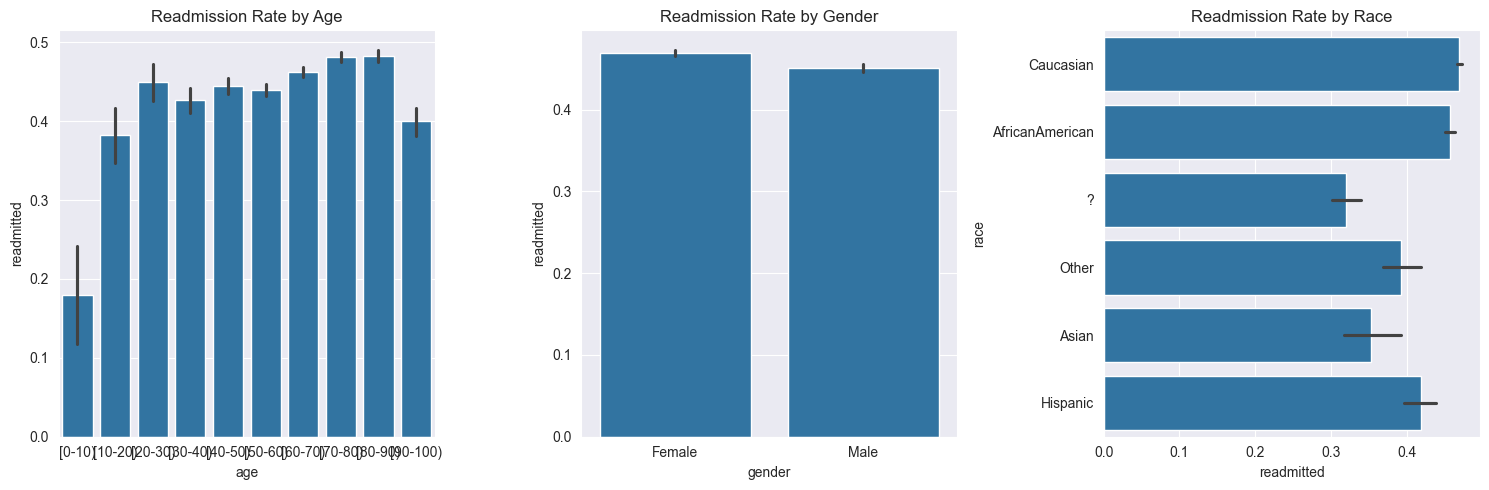

In [6]:
# Correlation with Readmission
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.barplot(x='age', y='readmitted', data=df, ax=axes[0])
axes[0].set_title('Readmission Rate by Age')

sns.barplot(x='gender', y='readmitted', data=df, ax=axes[1])
axes[1].set_title('Readmission Rate by Gender')

sns.barplot(y='race', x='readmitted', data=df, ax=axes[2])
axes[2].set_title('Readmission Rate by Race')

plt.tight_layout()
plt.show()


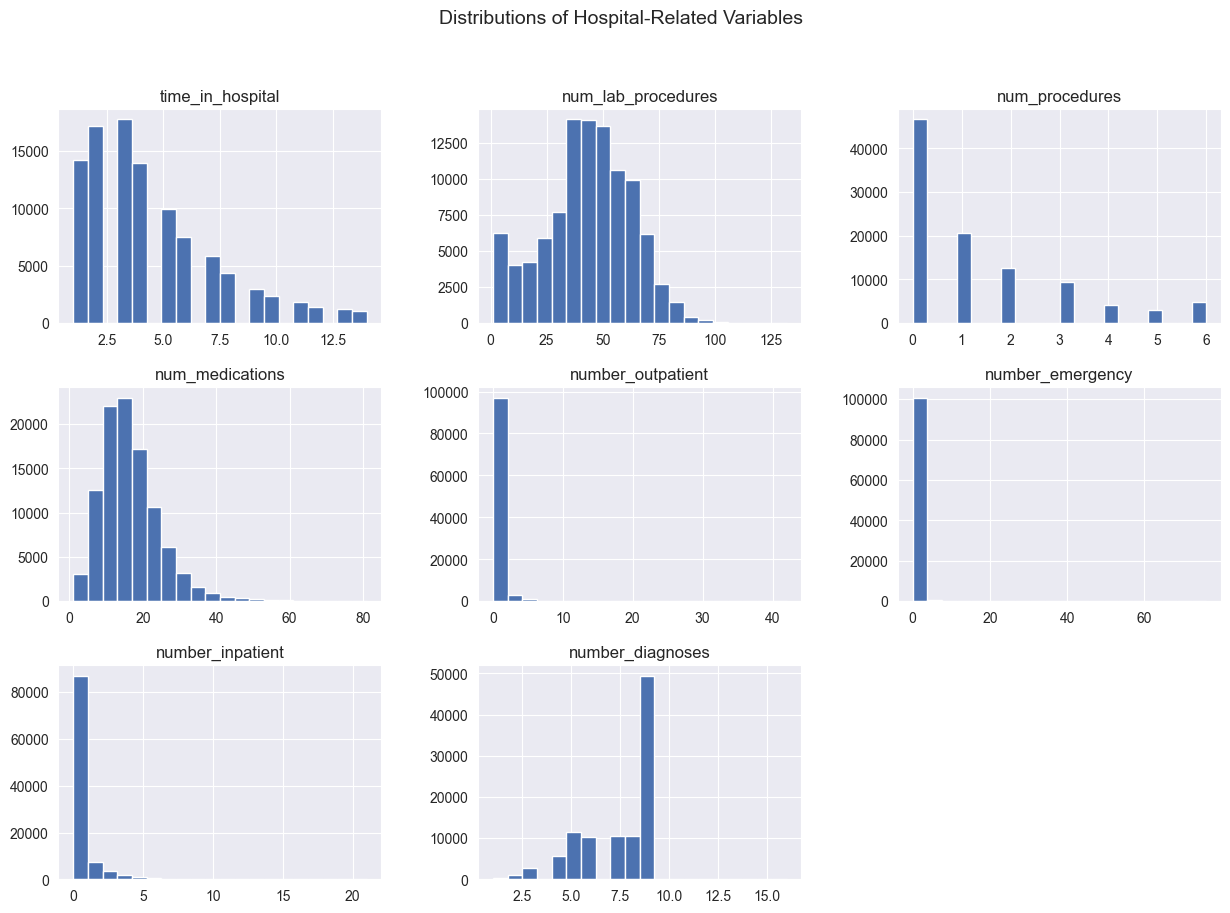

In [7]:
# Hospital Stay and Visits
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
             'num_medications', 'number_outpatient', 'number_emergency',
             'number_inpatient', 'number_diagnoses']

df[num_cols].hist(figsize=(15,10), bins=20, color='#4C72B0')
plt.suptitle('Distributions of Hospital-Related Variables', fontsize=14)
plt.show()



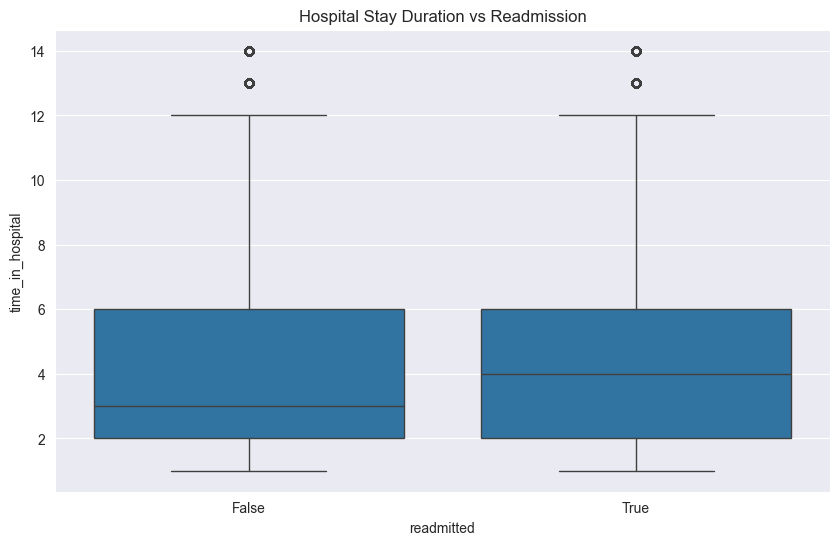

readmitted            1.000000
number_inpatient      0.217166
number_diagnoses      0.112531
number_emergency      0.102981
number_outpatient     0.082116
time_in_hospital      0.051287
num_medications       0.046751
num_lab_procedures    0.039245
num_procedures       -0.044734
Name: readmitted, dtype: float64

In [8]:
# Readmission Correlation
plt.figure(figsize=(10,6))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title('Hospital Stay Duration vs Readmission')
plt.show()

corrs = df[num_cols + ['readmitted']].corr()['readmitted'].sort_values(ascending=False)
corrs


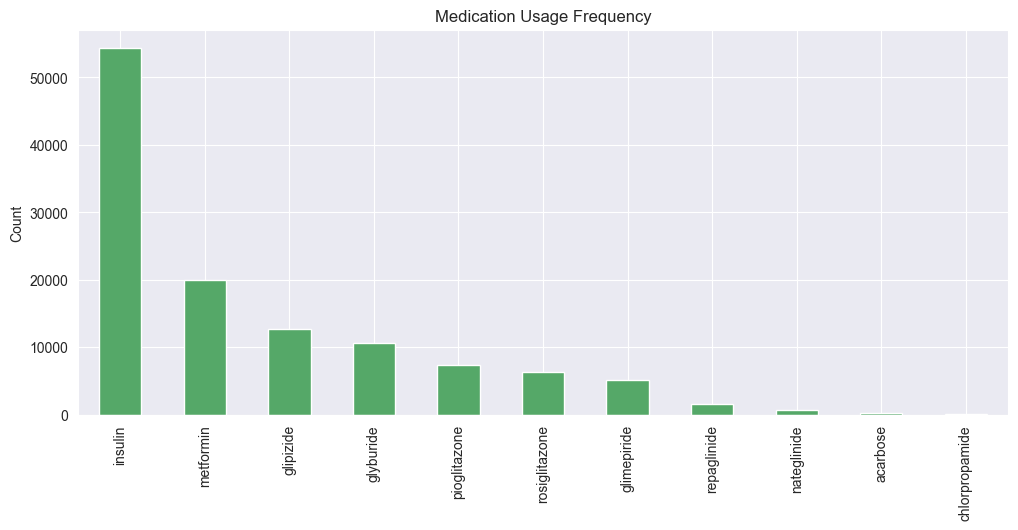

In [9]:
# Medication & Treatment Features
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'insulin']

med_usage = df[med_cols].apply(lambda x: (x != 'No').sum())
med_usage.sort_values(ascending=False).plot(kind='bar', figsize=(12,5), color='#55A868')
plt.title('Medication Usage Frequency')
plt.ylabel('Count')
plt.show()



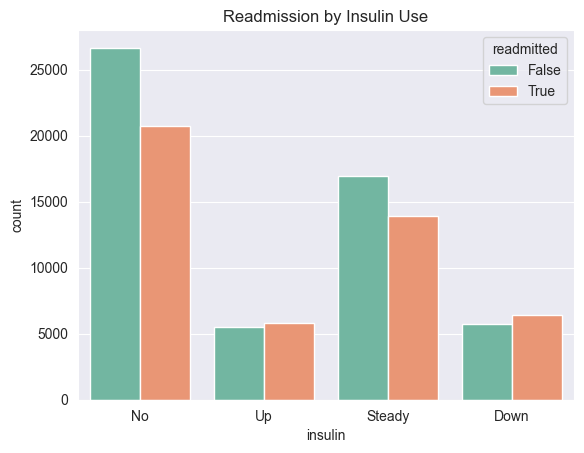

In [10]:
# Insulin and Readmission Relation
sns.countplot(x='insulin', hue='readmitted', data=df, palette='Set2')
plt.title('Readmission by Insulin Use')
plt.show()


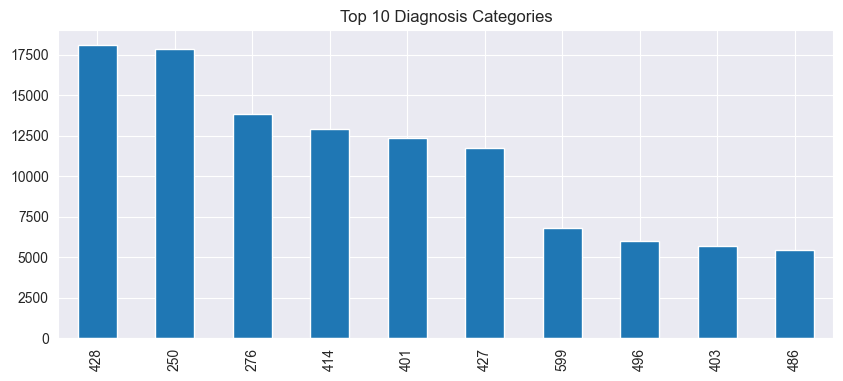

In [11]:
# Diagnostics
diag_cols = ['diag_1', 'diag_2', 'diag_3']
diag_counts = pd.concat([df[c] for c in diag_cols]).value_counts().head(10)
diag_counts.plot(kind='bar', figsize=(10,4))
plt.title('Top 10 Diagnosis Categories')
plt.show()


## Relationships and Correlations

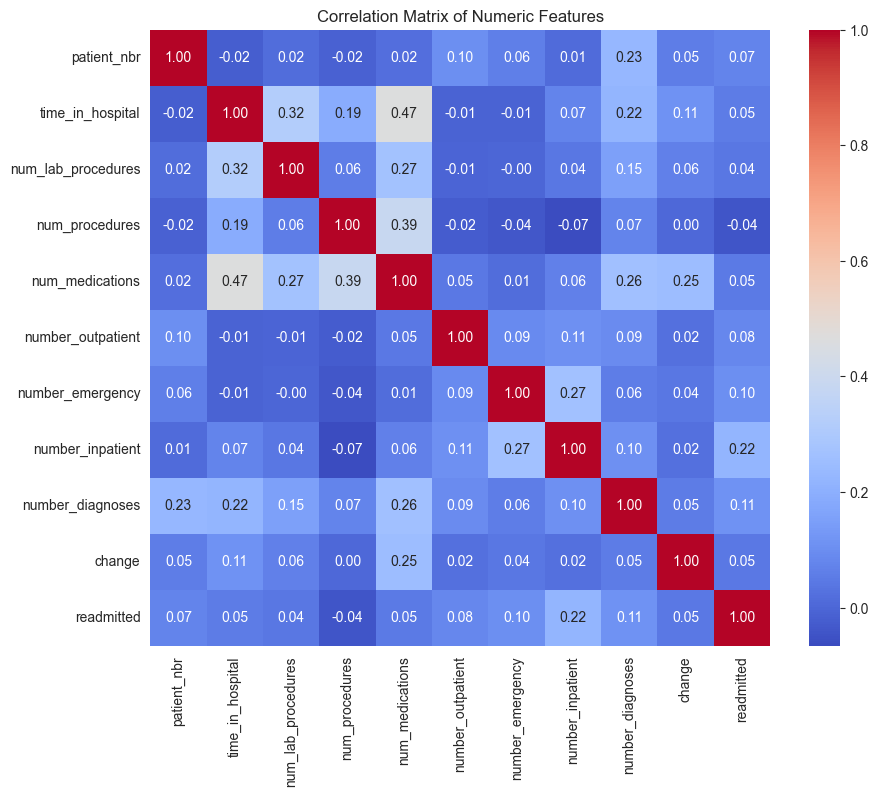

In [12]:
# Correlation matrix
corr = df.select_dtypes(include=['int64','float64','bool']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()


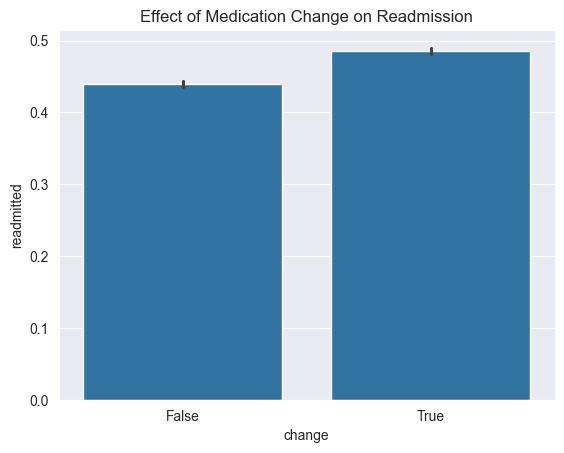

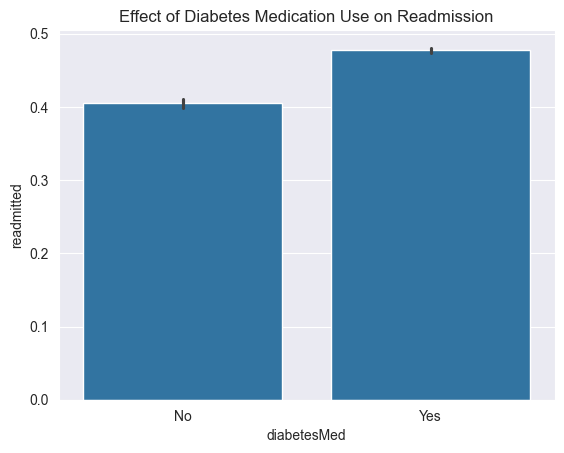

In [13]:
sns.barplot(x='change', y='readmitted', data=df)
plt.title('Effect of Medication Change on Readmission')
plt.show()

sns.barplot(x='diabetesMed', y='readmitted', data=df)
plt.title('Effect of Diabetes Medication Use on Readmission')
plt.show()


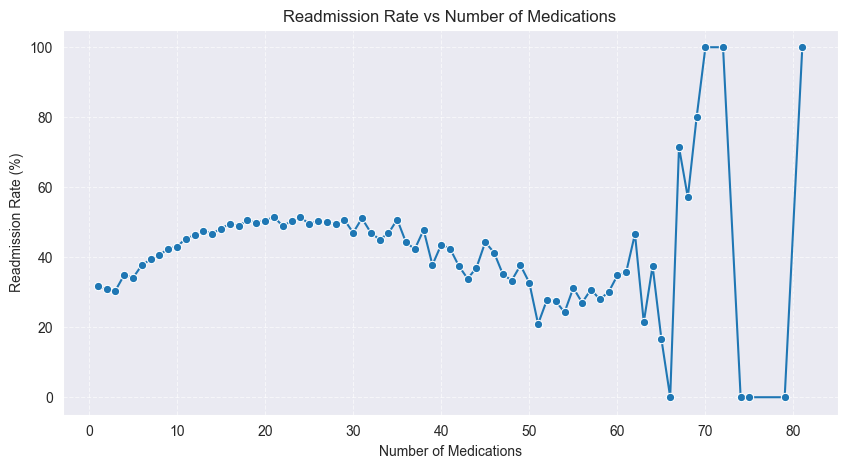

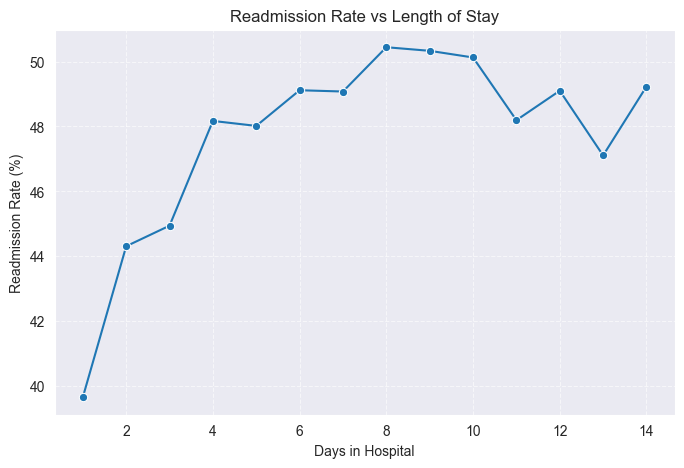

In [14]:
# Readmission Rate vs Number of Medications
med_group = (
    df.groupby('num_medications')['readmitted']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(x='num_medications', y='readmitted', data=med_group, marker='o')
plt.title('Readmission Rate vs Number of Medications')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Readmission Rate vs Length of Stay (Time in Hospital)
stay_group = (
    df.groupby('time_in_hospital')['readmitted']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(x='time_in_hospital', y='readmitted', data=stay_group, marker='o')
plt.title('Readmission Rate vs Length of Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



C:\Users\taula\AppData\Local\Temp\ipykernel_12960\3202951014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


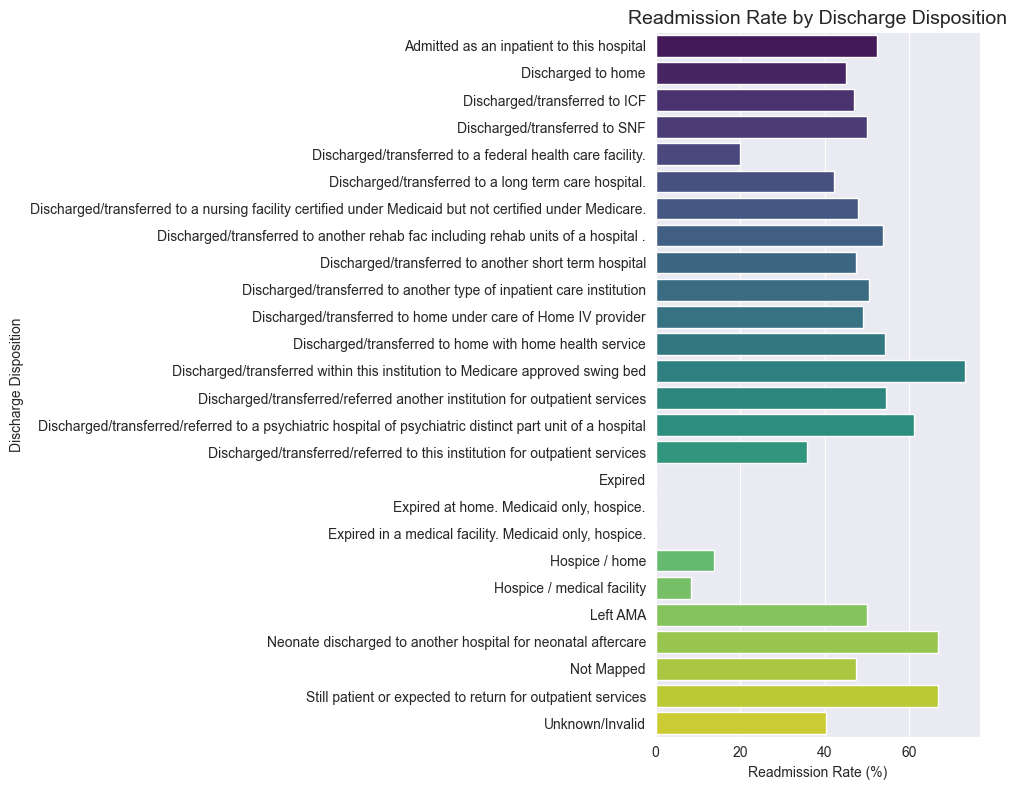

In [15]:
plt.figure(figsize=(10,8))
sns.barplot(
    y='discharge_disposition',
    x='readmitted',
    data=df.groupby('discharge_disposition')['readmitted'].mean().mul(100).reset_index(),
    palette='viridis'
)
plt.title('Readmission Rate by Discharge Disposition', fontsize=14)
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Discharge Disposition')
plt.tight_layout()
plt.show()


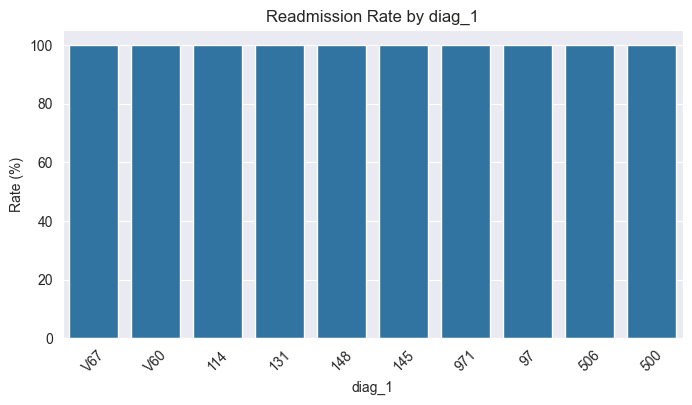

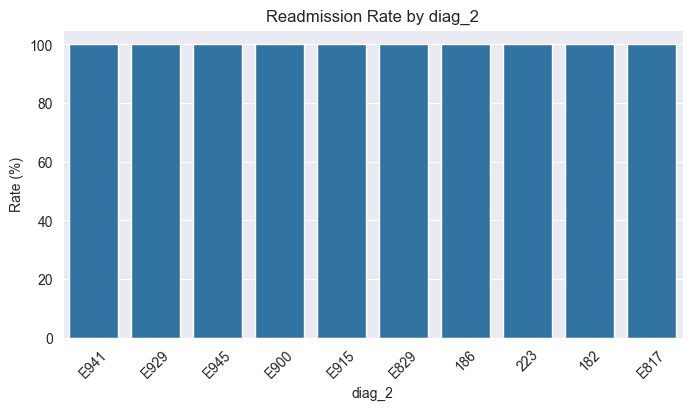

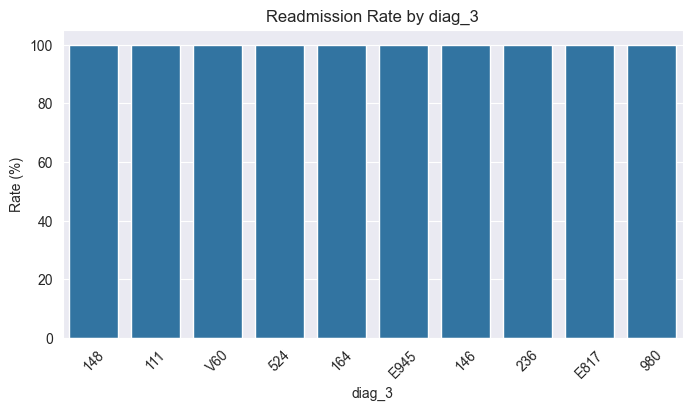

In [19]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']
for c in diag_cols:
    rates = df.groupby(c)['readmitted'].mean().mul(100).sort_values(ascending=False).head(10)
    plt.figure(figsize=(8,4))
    sns.barplot(x=rates.index, y=rates.values)
    plt.title(f'Readmission Rate by {c}')
    plt.ylabel('Rate (%)')
    plt.xticks(rotation=45)
    plt.show()


High Readmission (>75%)


,diag_1,readmission_rate
713,V67,100.0
710,V60,100.0
4,114,100.0



Medium Readmission (25–75%)


,diag_1,readmission_rate
517,731,75.0
332,494,75.0
639,916,75.0



Low Readmission (<25%)


,diag_1,readmission_rate
672,970,25.0
606,863,25.0
239,382,25.0


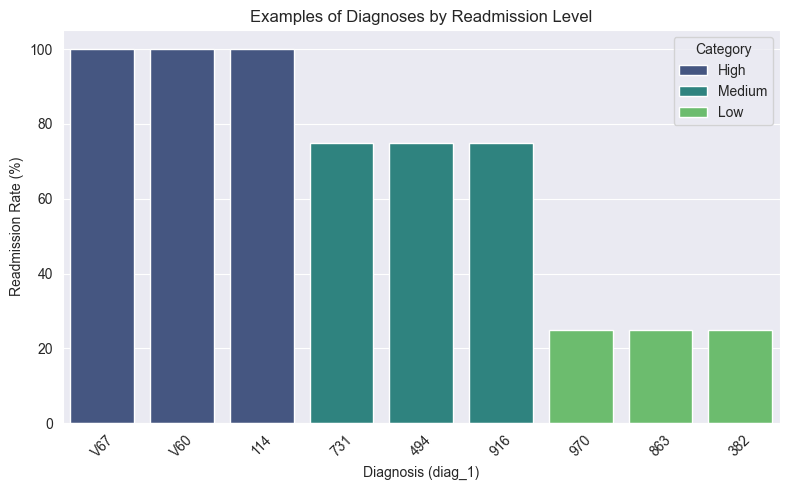

In [21]:
# Compute readmission rate (%) per primary diagnosis
diag1_rates = (
    df.groupby('diag_1')['readmitted']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'readmitted': 'readmission_rate'})
)

# Sort descending by rate
diag1_rates = diag1_rates.sort_values('readmission_rate', ascending=False)

# Filter into categories
high = diag1_rates[diag1_rates['readmission_rate'] > 75].head(3)
medium = diag1_rates[(diag1_rates['readmission_rate'] > 25) & (diag1_rates['readmission_rate'] <= 75)].head(3)
low = diag1_rates[diag1_rates['readmission_rate'] <= 25].head(3)

# Display them
print("High Readmission (>75%)")
display(high)

print("\nMedium Readmission (25–75%)")
display(medium)

print("\nLow Readmission (<25%)")
display(low)

# Optional: visualize them together
combined = pd.concat([high.assign(Category='High'),
                      medium.assign(Category='Medium'),
                      low.assign(Category='Low')])

plt.figure(figsize=(8,5))
sns.barplot(x='diag_1', y='readmission_rate', hue='Category', data=combined, palette='viridis')
plt.title('Examples of Diagnoses by Readmission Level')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Diagnosis (diag_1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


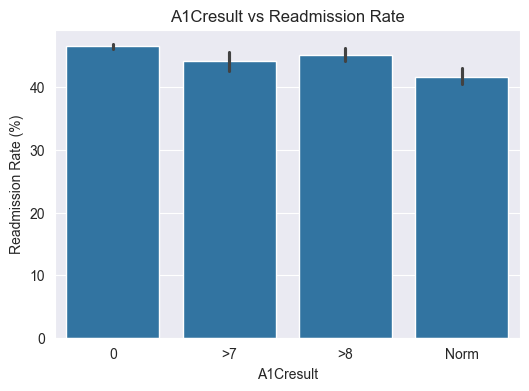

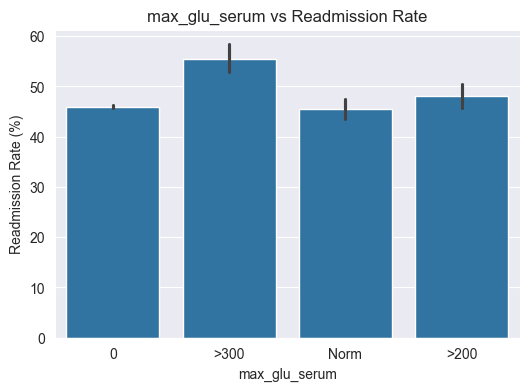

In [22]:
for col in ['A1Cresult', 'max_glu_serum']:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='readmitted', data=df, estimator=lambda x: 100 * np.mean(x))
    plt.ylabel('Readmission Rate (%)')
    plt.title(f'{col} vs Readmission Rate')
    plt.show()


## Key findings

### Dataset Summary
This analysis examined **101 742 hospital encounters** from diabetes patients across 36 different features including demographics, admission details, medications, and readmission status.

### Finding 1: Age Distribution and Readmission Risk
- **Key Insight**: Patients aged 60+ represent 65% of hospital encounters, with the highest readmission rates in the 70-80 age group.
- **Implication**: Targeted intervention programs for elderly patients could significantly reduce readmissions.
- **Observation**: Lower age ranges can be grouped

### Finding 2: Length of Hospital Stay
- **Key Insight**: Patients which stayed longer than 3 days have higher chance of readmission with the highest being around 8 days
- **Implication**: Longer stays indicates more observations with higher probability of coming again.

### Finding 3: Diagnosis Patterns
- **Key Insight**: The analysis of **primary diagnoses (`diag_1`)** shows that certain diagnosis groups have **dramatically higher readmission rates**, with some exceeding **75 %**.
In contrast, other diagnoses show rates below 25 %.
- **Implication**: Diagnosis type is a **strong predictive feature** for modeling hospital readmissions.

### Finding 4: Number of Medication
- **Key Insight**: From 0 to around 20 medications, the readmission rate increases steadily, indicating patients taking more medications are more difficult cases. Between 20–40 medications, the rate stabilizes around 45–50 %, suggesting a plateau. After 60 medications the data has spikes up to 100% likely due to very few patients in this extremes
- **Implication**: The number of medications should be included as a continuous predictive variable, but values above 60 should be handled carefully

## Possible Feature Engineering

- The ICD-9 codes could be summarized to 18 categories, could be more helpful for ML than 999+ different codes
- Instead of readmission (yes/no) add category (<30 / >30 / NO)
- Depending on what model to use, encode categories
- Normalizing and Scaling
- Turn raw data into meaningful predictors like high number of recurring visits means higher chance of readmission